# Time-Series Analysis of Microbial and ARG Abundance

## 1. Load and Understand the Data

This step will load the microbial abundance and ARG Abundance data and seperate the microbial data and arg data into seperate dataframe for easier analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
# File path to your merged CSV file
file_path = "./examples/example_data/merged_arg_gene_abundance_and_taxa_abundance.csv"  # update with actual path if needed

# Read the CSV into a DataFrame
merged_df = pd.read_csv(file_path,keep_default_na=False)

# Preview the first few rows
print(merged_df.head())

      CITY        PLANT COUNTRY  relative_week      COLLECTION_DATE  \
0  Bologna  Gruppo HERA   Italy             58  2020-03-12 00:00:00   
1  Bologna  Gruppo HERA   Italy             59  2020-03-24 00:00:00   
2  Bologna  Gruppo HERA   Italy             61  2020-04-07 00:00:00   
3  Bologna  Gruppo HERA   Italy             63  2020-04-21 00:00:00   
4  Bologna  Gruppo HERA   Italy             65  2020-05-05 00:00:00   

   sample_id  blaOXA-58_1_AY665723  aph(3'')-Ib_2_AF024602  blaAER-1_1_U14748  \
0  1014216_1                    34                     448                 21   
1  1014218_1                    29                     472                 14   
2  1014220_1                    20                     298                 20   
3  1014222_1                    46                     379                 35   
4  1014224_1                    76                     399                 27   

   aph(3')-Ia_3_EF015636  ...  Rubrivivax  Streptococcus  Telluria   Thauera  \
0     

In [26]:
microbial_abundance_classes = ['Acidovorax', 'Acinetobacter', 'Aeromonas', 'Aliarcobacter',
       'Aquabacterium_A', 'Bacteroides', 'Brachymonas', 'Brevefilum',
       'Brevundimonas', 'Cloacibacterium', 'Comamonas', 'Competibacter_A',
       'Enterobacter', 'Fermentibacter', 'Flavobacterium', 'Giesbergeria',
       'Hydrogenophaga', 'JAGOYM01', 'Janthinobacterium', 'Kaistella',
       'Lactococcus_A', 'Lenti-01', 'Microthrix', 'Moraxella_A',
       'Neisseria', 'Novosphingobium', 'Ottowia', 'Paracoccus',
       'Phocaeicola', 'Prevotella', 'Propionivibrio', 'Pseudomonas_E',
       'Pseudoxanthomonas', 'Pseudoxanthomonas_A', 'Psychrobacter',
       'Rubrivivax', 'Streptococcus', 'Telluria', 'Thauera',
       'Thermomonas', 'Thiothrix', 'Tolumonas', 'Trichococcus', 'UBA1413','merged']

In [27]:
metadata_columns = ['COLLECTION_DATE', 'sample_id', 'CITY', 'relative_week']

In [28]:
abundance_df = merged_df[metadata_columns + microbial_abundance_classes]

In [29]:
abundance_df

,COLLECTION_DATE,sample_id,CITY,relative_week,Acidovorax,Acinetobacter,Aeromonas,Aliarcobacter,Aquabacterium_A,Bacteroides,Brachymonas,Brevefilum,Brevundimonas,Cloacibacterium,Comamonas,Competibacter_A,Enterobacter,Fermentibacter,Flavobacterium,Giesbergeria,Hydrogenophaga,JAGOYM01,Janthinobacterium,Kaistella,Lactococcus_A,Lenti-01,Microthrix,Moraxella_A,Neisseria,Novosphingobium,Ottowia,Paracoccus,Phocaeicola,Prevotella,Propionivibrio,Pseudomonas_E,Pseudoxanthomonas,Pseudoxanthomonas_A,Psychrobacter,Rubrivivax,Streptococcus,Telluria,Thauera,Thermomonas,Thiothrix,Tolumonas,Trichococcus,UBA1413,merged
0,2020-03-12 00:00:00,1014216_1,Bologna,58,0.276368,0.031886,0.007573,0.005577,0.000851,0.001645,0.025107,0.000003,0.004187,0.003837,0.062122,0.000527,0.000241,0.000007,0.006122,0.021889,0.002101,0.007536,0.002004,0.002554,0.001356,0.001543,0.000062,0.010445,0.040534,0.002000,0.073051,0.005504,0.001198,0.001735,0.013523,0.010368,0.006977,0.016293,0.001793,0.000296,0.000989,0.000557,0.009553,0.009562,0.000857,0.000597,0.005971,3.410770e-06,0.323095
1,2020-03-24 00:00:00,1014218_1,Bologna,59,0.202939,0.027852,0.006944,0.006824,0.000683,0.001525,0.011663,0.000063,0.009610,0.003248,0.031996,0.000181,0.003406,0.000007,0.004867,0.038511,0.001782,0.004121,0.000716,0.003993,0.000483,0.001284,0.000048,0.022331,0.020644,0.001087,0.028066,0.017349,0.000934,0.001869,0.016300,0.014292,0.004313,0.015022,0.004182,0.001612,0.000921,0.000614,0.010319,0.015765,0.002310,0.001242,0.006793,1.933750e-04,0.451094
2,2020-04-07 00:00:00,1014220_1,Bologna,61,0.151028,0.017902,0.004478,0.006025,0.067315,0.000566,0.007623,0.000096,0.002104,0.001992,0.022012,0.000180,0.000573,0.000007,0.004323,0.023787,0.005681,0.004577,0.001203,0.001768,0.000172,0.000706,0.008607,0.002891,0.005256,0.005012,0.065601,0.002125,0.000711,0.001390,0.006588,0.022327,0.002940,0.010708,0.000862,0.000715,0.001632,0.000634,0.010605,0.014747,0.005864,0.000375,0.007356,1.763710e-04,0.498759
3,2020-04-21 00:00:00,1014222_1,Bologna,63,0.195505,0.053402,0.004095,0.001273,0.008998,0.002688,0.007945,0.000011,0.007314,0.004183,0.012189,0.000227,0.000389,0.000009,0.009750,0.029282,0.003616,0.000346,0.084977,0.006536,0.000129,0.002332,0.001459,0.005081,0.004615,0.002737,0.013397,0.013410,0.006428,0.002394,0.011148,0.079479,0.003641,0.010463,0.012184,0.000228,0.000686,0.003563,0.008061,0.012298,0.006840,0.001166,0.002078,2.503500e-06,0.363446
4,2020-05-05 00:00:00,1014224_1,Bologna,65,0.245590,0.045212,0.002893,0.010809,0.000382,0.000837,0.031531,0.000010,0.001759,0.014290,0.063272,0.000154,0.000413,0.000016,0.005425,0.018826,0.002650,0.003589,0.001460,0.003688,0.000438,0.000803,0.000247,0.028364,0.035069,0.001958,0.029698,0.003231,0.000458,0.000942,0.014420,0.015486,0.005923,0.027248,0.002795,0.000570,0.004664,0.001591,0.024527,0.029836,0.004378,0.000992,0.006933,5.820560e-06,0.306620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,2021-09-22 00:00:00,1014209_1,Rotterdam,138,0.078475,0.016356,0.045089,0.023153,0.000144,0.002341,0.013407,0.000011,0.004307,0.006041,0.013564,0.000124,0.002351,0.000019,0.007983,0.065783,0.005291,0.000382,0.000902,0.045616,0.001668,0.001438,0.000005,0.000817,0.004001,0.001594,0.008974,0.000439,0.005331,0.007104,0.027962,0.043880,0.001853,0.003380,0.090908,0.000149,0.001684,0.005169,0.013070,0.004231,0.008961,0.014368,0.004064,1.988390e-06,0.417609
231,2021-09-29 00:00:00,1014210_1,Rotterdam,139,0.068995,0.008204,0.036951,0.011697,0.000867,0.002920,0.021036,0.000008,0.004141,0.009240,0.020237,0.000088,0.004475,0.000015,0.006716,0.061776,0.009864,0.000235,0.000584,0.014123,0.001836,0.013872,0.000006,0.000592,0.005018,0.004571,0.043776,0.000722,0.004194,0.008324,0.024992,0.014661,0.002802,0.006260,0.064956,0.000284,0.001400,0.001012,0.010696,0.012681,0.010376,0.025436,0.001853,2.022400e-06,0.457504
232,2021-10-07 00:0

In [32]:
arg_df =merged_df.drop(columns=microbial_abundance_classes+['PLANT','COUNTRY'])
arg_df

,CITY,relative_week,COLLECTION_DATE,sample_id,blaOXA-58_1_AY665723,aph(3'')-Ib_2_AF024602,blaAER-1_1_U14748,aph(3')-Ia_3_EF015636,blaTEM-1D_1_AF188200,tet(O/32/O)_5_FP929050,lnu(C)_1_AY928180,dfrA32_1_GU067642,aph(3')-VI_1_KC170992,aadA1_3_JQ414041,aadD_2_M19465,tet(O/32/O)_1_JQ740052,tet(Q)_1_L33696,tet(C)_3_AF055345,aadA11_1_AY144590,aac(3)-IVa_1_X01385,blaOXA-5_1_AF347074,erm(B)_10_U86375,dfrA1_1_FJ591049,lnu(B)_1_AJ238249,aac(3)-IIa_3_X13543,cfr(C)_2_CANB01000378,mph(G)_1_AB571865,lnu(F)_1_EU118119,mph(A)_1_D16251,mef(A)_4_HG423652,blaOXA-20_2_AF024602,tet(B)_3_AJ277653,ant(2'')-Ia_3_X74412,blaGES-3_1_AB113580,ere(A)_6_DQ157752,blaFOX-4_1_AJ277535,tet(40)_2_AM419751,cat(pC194)_1_NC_002013,blaOXA-373_1_HG931732,aph(6)-Id_5_18676889,mef(C)_1_AB571865,cfxA_1_U38243,blaOXA-28_1_AF231133,str_1_X92946,VanHBX_1_AF192329,mef(A)_3_AF227520,ant(3'')-Ia_1_X02340,aadA7_2_AB114632,aph(2'')-Ia_3_AJ536195,blaOXA-119_1_DQ767903,aph(4)-Ia_1_V01499,cfxA6_1_GQ342996,ere(D)_1_KP265721,ole(C)_1_L06249,ant(6)-Ia_3_KF864551,ant(6)-Ia_2_KF421157,aph(3')-III_1_M26832,aadA10_1_U37105,tet(32)_2_EF626943,blaNPS_1_AY027589,poxtA_1_MF095097,mph(E)_1_DQ839391,qnrD2_1_KF055448,sul1_9_AY963803,ant(3'')-Ii-aac(6')-IId_1_AF453998,blaOXA-47_1_AY237830,blaOXA-415_1_KJ865754,ant(6)-Ia_1_AF330699,tet(S/M)_2_AY534326,tet(W)_3_AJ427421,dfrA14_5_DQ388123,sul2_2_AY034138,tet(M)_9_X56353,tet(X)_1_GU014535,aadA13_1_AY713504,mdf(A)_1_Y08743,tet(A)_3_AY196695,catP_1_U15027,qnrVC7_1_KM555152,cepA-44_1_U05885,blaCARB-8_1_AY178993,aac(6')-Ib_2_M23634,lsa(E)_1_JX560992,oqxB_1_EU370913,catB3_1_AJ009818,erm(G)_2_L42817,blaACT-9_1_HQ693810,msr(D)_3_AF227520,fosE_1_AB901041,nimF_1_AJ515145,tet(O/W/32/O)_1_EF065523,catQ_1_M55620,aph(3')-Ib_2_AJ744860,aadA16_1_EU675686,aadA5_1_AF137361,tet(39)_1_KT346360,erm(F)_1_M14730,rmtE_1_GU201947,msr(E)_1_FR751518,cmlA1_1_M64556,tet(G)_3_S52437,lnu(G)_1_KX470419,VanHAX_2_M97297,blaACI-1_1_AJ007350,blaMIR-1_1_M37839,tet(44)_1_NZ_ABDU01000081,aac(6')-Im_1_AF337947,blaMOX-1_1_D13304,blaBEL-1_1_DQ089809,mef(B)_1_FJ196385,qnrS5_1_HQ631377,cat_2_M35190,aadA2_1_NC_010870,erm(X)_3_U21300,blaOXA-198_1_HQ634775,aph(2'')-Id_1_AF016483,fosA5_1_EU195449,mph(A)_2_U36578,floR_2_AF118107,oqxA_1_EU370913,VanHDX_7_AB242319,catB8_1_AF227506,qnrB5_1_DQ303919,blaOXY-1-3_3_AY077482,cmx_1_U85507,catB2_1_AF047479,blaOXA-347_1_ACWG01000053,blaOXA-60d_1_AY664506,blaOXA-284_1_APRU01000004,VanC1XY_2_DQ022190,cphA1_4_AY261376,mcr-5.1_1_KY807921,aac(3)-Ic_1_AJ511268,blaACC-3_1_AF180958,mph(F)_1_AM260957,dfrA7_5_AJ419170,aac(3)-Ia_1_X15852,blaDHA-1_1_Y16410,blaCTX-M-28_6_AJ549244,blaOXA-25_1_AF201826,blaCMY-14_1_AJ555825,aac(6')-IIc_1_NC_012555,ARR-6_3_JF922883,tet(31)_1_GQ283908,blaOXA-209_1_JF268688,sul4_1_MG649393,aph(2'')-Ib_3_KF652098,ant(6)-Ib_1_FN594949,catA1_1_V00622,blaVEB-1_3_DQ393569,tet(X3)_1_MK134375,dfrB1_1_U36276,ARR-3_4_FM207631,blaOXA-9_1_KQ089875,ampS_1_X80276,blaVIM-10_1_AY524989,cphA6_1_AY227052,VanHDX_5_AY489045,blaOXA-427_1_KX827604,tet(D)_1_AF467077,fosA2_1_EU487198,blaCARB-4_1_FJ785525,tetA(46)_1_HQ652506,aac(3)-VIa_1_M88012,aac(6')-If_1_X55353,blaSHV-9_1_S82452,nimJ_1_NZ_JH815495,dfrA7_4_FN563072,blaOXA-296_1_APOH01000009,erm(A)_2_AF002716,fosA_2_AGDM01000012,dfrA30_1_AM997279,blaACC-4_1_GU256641,dfrA22_4_AJ628423,blaOKP-A-1_1_AM051138,blaPER-4_1_EU748544,aph(2'')-Ig_1_CP004067,rmtF_1_JQ808129,blaOXA-491_1_KU721148,aac(6')-Ib-Suzhou_1_EU085533,blaLEN2_1_AY037780,nimE_1_AJ244018,aph(3')-IIc_1_AM743169,aac(3)-IIIc_1_L06161,catS_1_X74948,aac(6')-Il_1_U13880,dfrA12_10_FM877486,VanG2XY_1_FJ872410,mcr-3.17_1_MH332767,aac(6')-IIa_1_M29695,aph(6)-Ic_1_X01702,erm(C)_15_U82607,fosE_2_AY029772,blaOXA-484_1_KR401105,blaCARB-6_1_AF030945,blaOXA-372_1_KJ746496,erm(47)_1_KU612222,blaBES-1_1_AF234999,cmlB1_1_AM296481,blaPLA-6A_1_DQ251478,blaOXY-2-1_1_AJ871866,blaDES-1_1_AF426161,nimD_1_X76949,blaL1_3_EF126059,ant(9)-Ia_1_X02588,dfrA3_1_J03306,blaACT-15_1_JX440356,tet(E)_2_L06940,imiS_1_Y10415,tet(T)_2_AY660530,blaEBR-1_1_AF416700,tetA(P)_2_L20800,tetB(P)_1_NC_0

## 2. Data Cleaning & Preprocessing
- Check for Null values and see for the null values 
- Normalize ARG and microbial abundance (if needed, e.g., TPM, log, CLR transformation)

In [47]:
arg_df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

/tmp/ipykernel_1534422/3341693708.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



## 3. Exploratory Data Analysis (EDA)

- Temporal trends: Line plots of ARGs and taxa over time by city/plant

- Distribution: Histograms or density plots of abundance values

- Heatmaps: ARG and taxa profiles across sites

- Correlation matrices: ARG vs microbial taxa

- Principal Component Analysis (PCA)/t-SNE: Dimensionality reduction to identify site or time-based clusters

### Heatmaps: ARG and taxa profiles across sites 

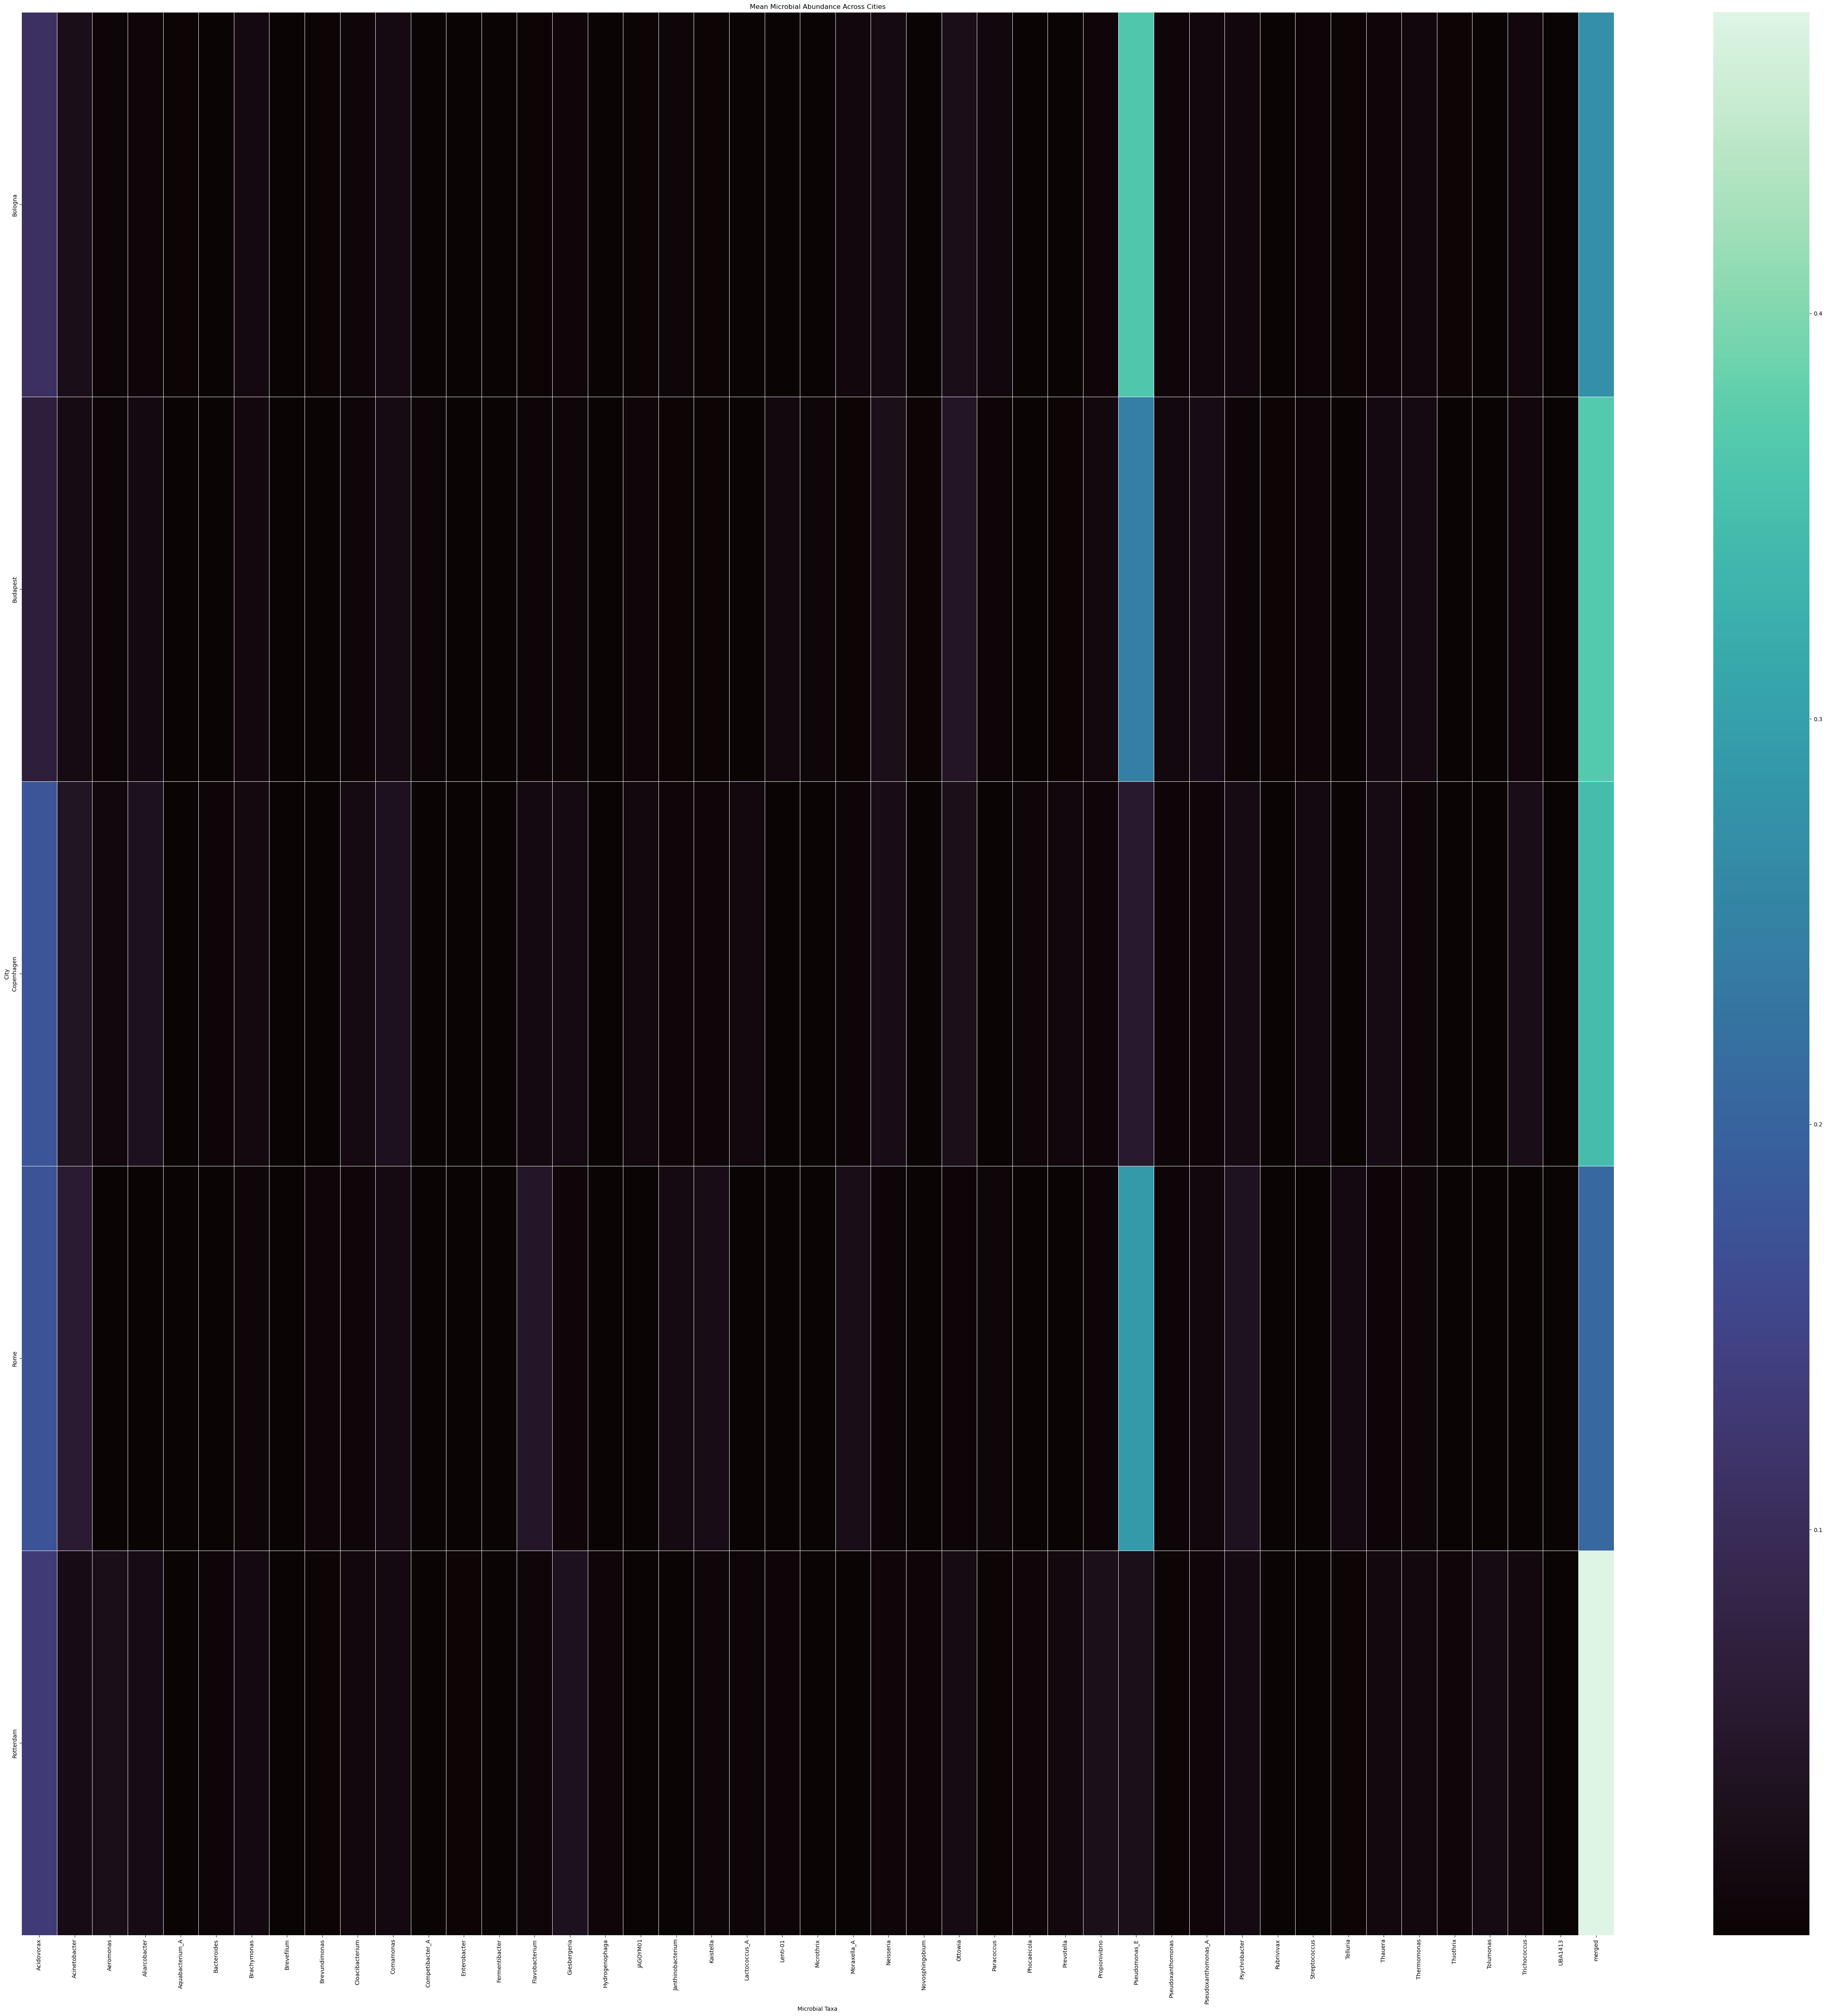

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define metadata columns
metadata_cols = ['CITY', 'relative_week', 'COLLECTION_DATE', 'sample_id']

# Extract microbial abundance columns (remove metadata)
taxa_data_only = abundance_df.drop(columns=metadata_cols)

# Keep only numeric taxa columns (some could accidentally be non-numeric)
taxa_data_numeric = taxa_data_only.select_dtypes(include='number')

# Add CITY column back for grouping
taxa_data_numeric['CITY'] = abundance_df['CITY']

# Group by CITY and compute the mean
taxa_city_avg = taxa_data_numeric.groupby('CITY').mean()

# Plot the heatmap
plt.figure(figsize=(50, 50))
sns.heatmap(taxa_city_avg, cmap='mako', linewidths=0.5)

# Style the plot
plt.title("Mean Microbial Abundance Across Cities")
plt.ylabel("City")
plt.xlabel("Microbial Taxa")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


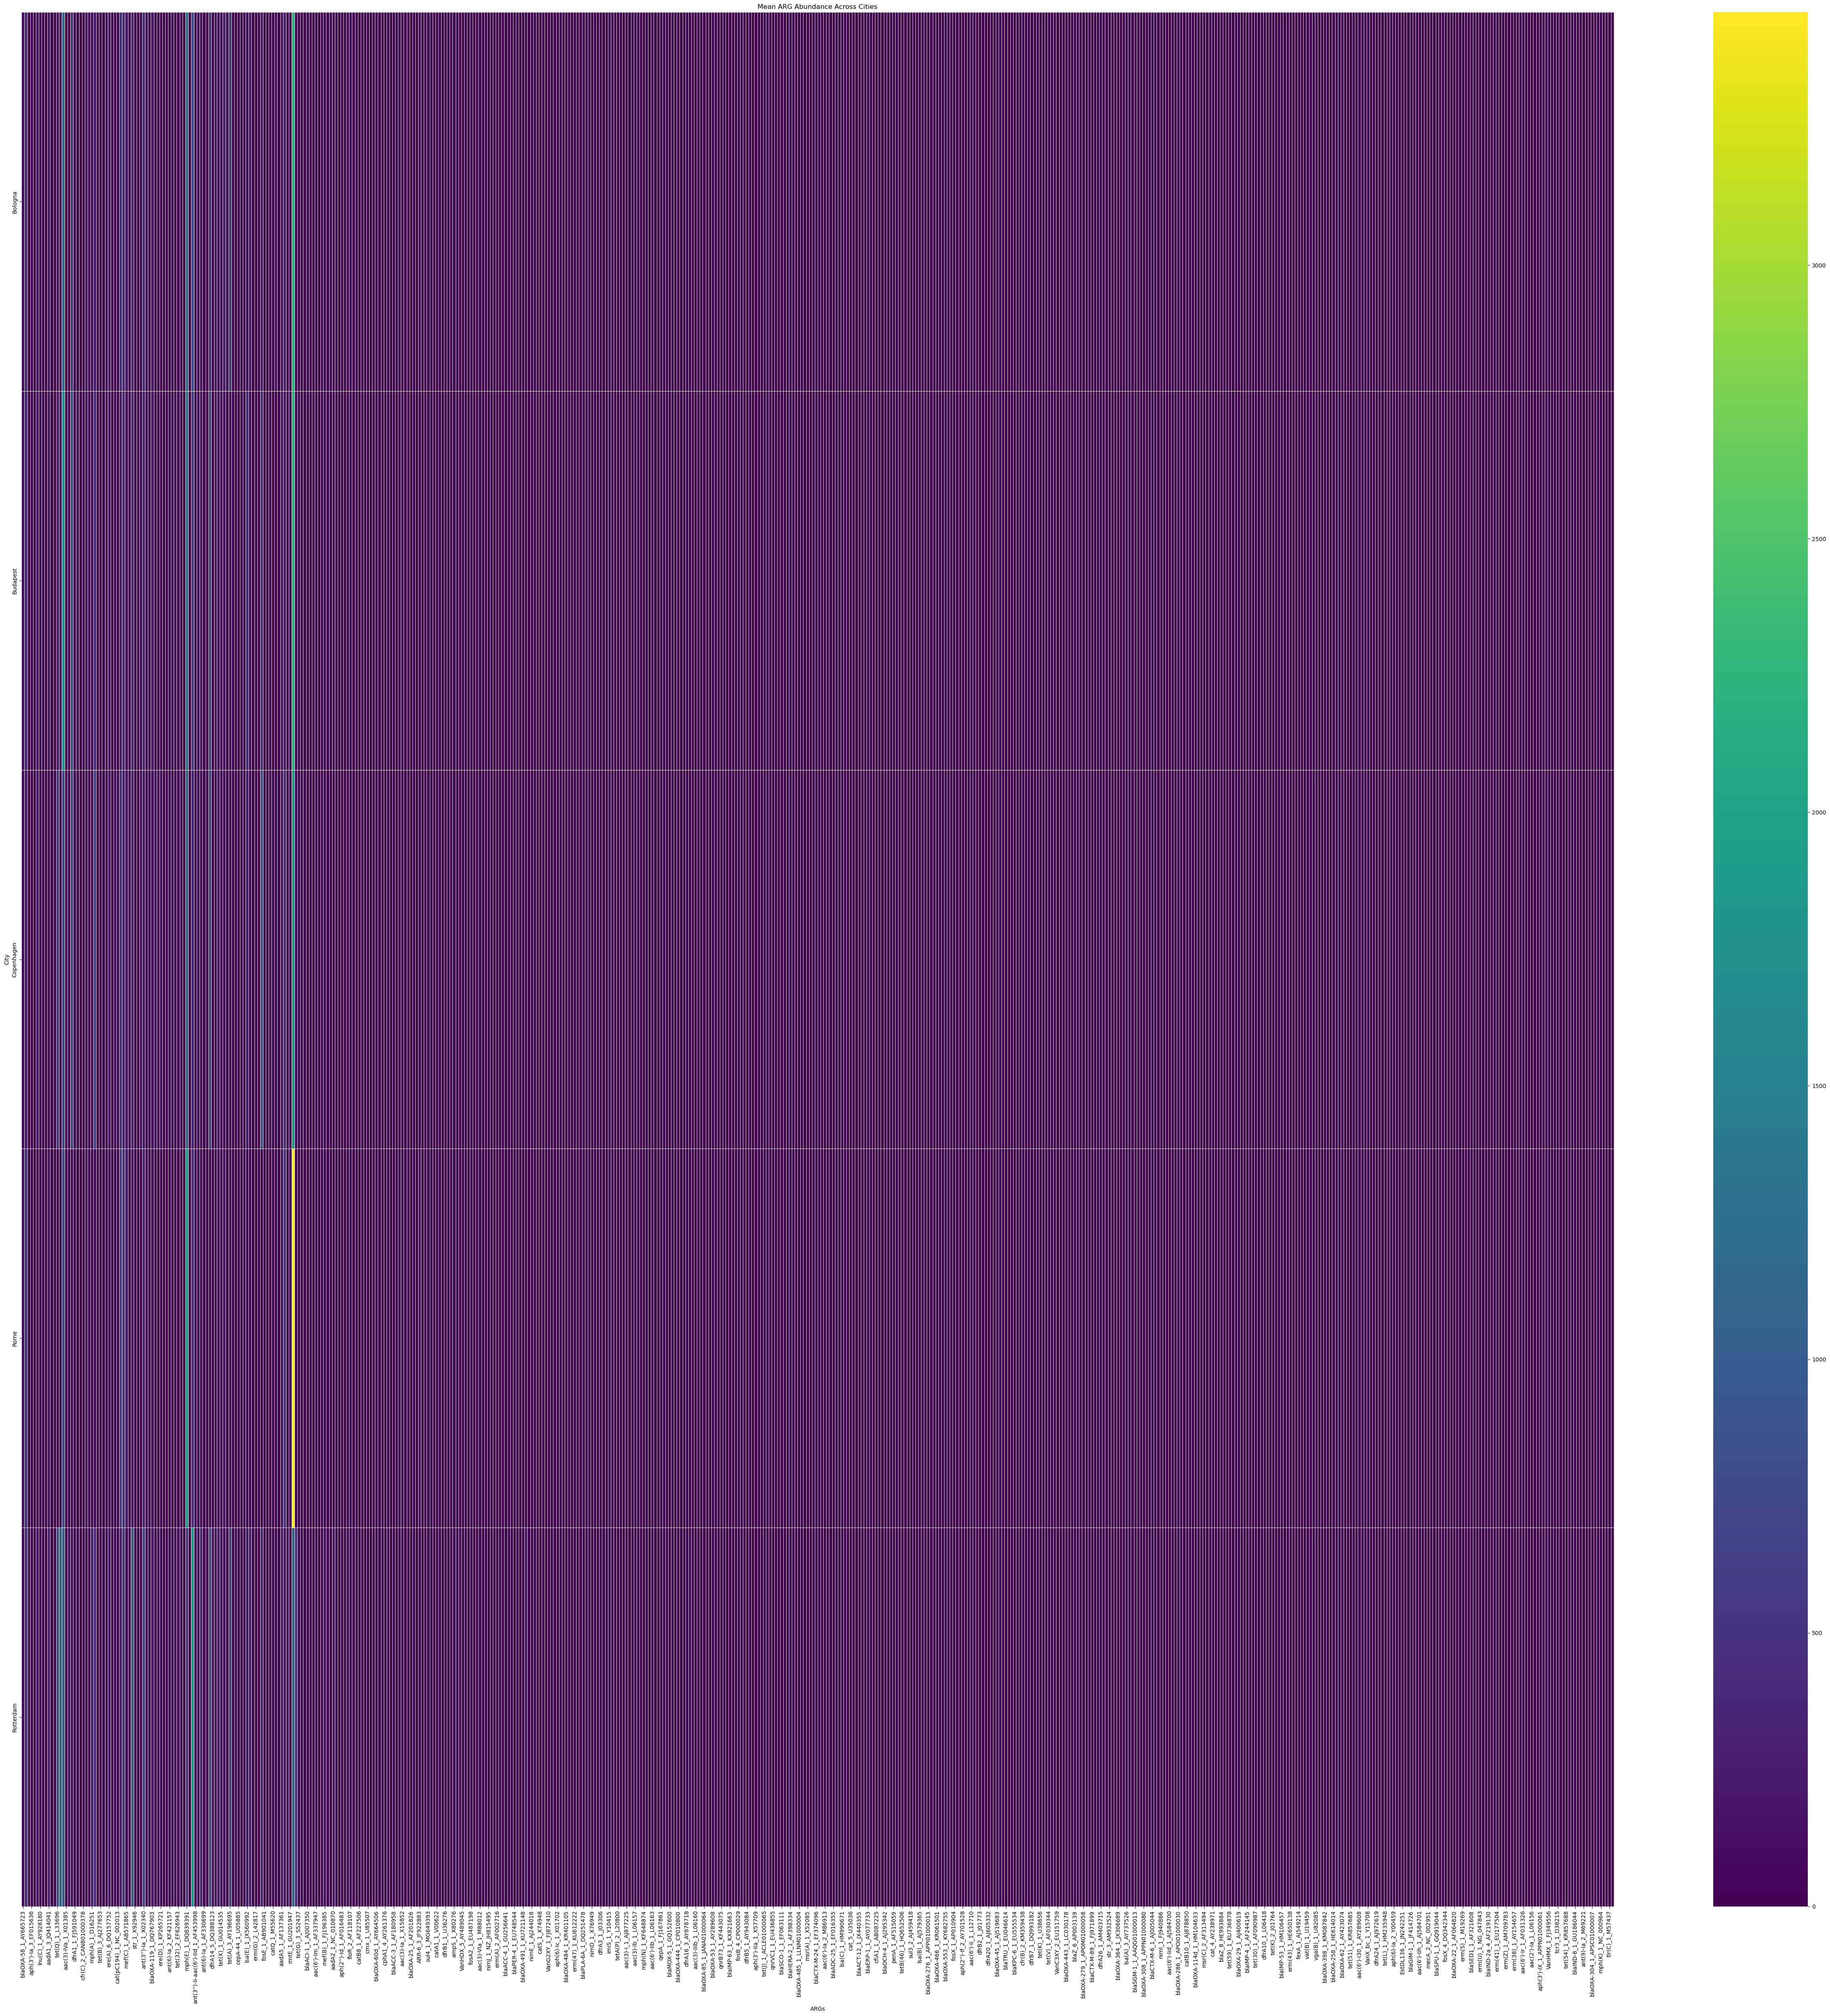

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define metadata columns
metadata_cols = ['CITY', 'relative_week', 'COLLECTION_DATE', 'sample_id']

# Step 1: Get only numeric ARG columns
arg_data_only = arg_df.drop(columns=metadata_cols)
arg_data_numeric = arg_data_only.select_dtypes(include='number')

# Step 2: Merge CITY column back for grouping
arg_data_numeric['CITY'] = arg_df['CITY']

# Step 3: Group by city and compute mean ARG abundance
arg_city_avg = arg_data_numeric.groupby('CITY').mean()

# Step 4: Plot heatmap
plt.figure(figsize=(50, 50))
sns.heatmap(arg_city_avg, cmap='viridis', linewidths=0.5)
plt.title("Mean ARG Abundance Across Cities")
plt.ylabel("City")
plt.xlabel("ARGs")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Temporal Trends 

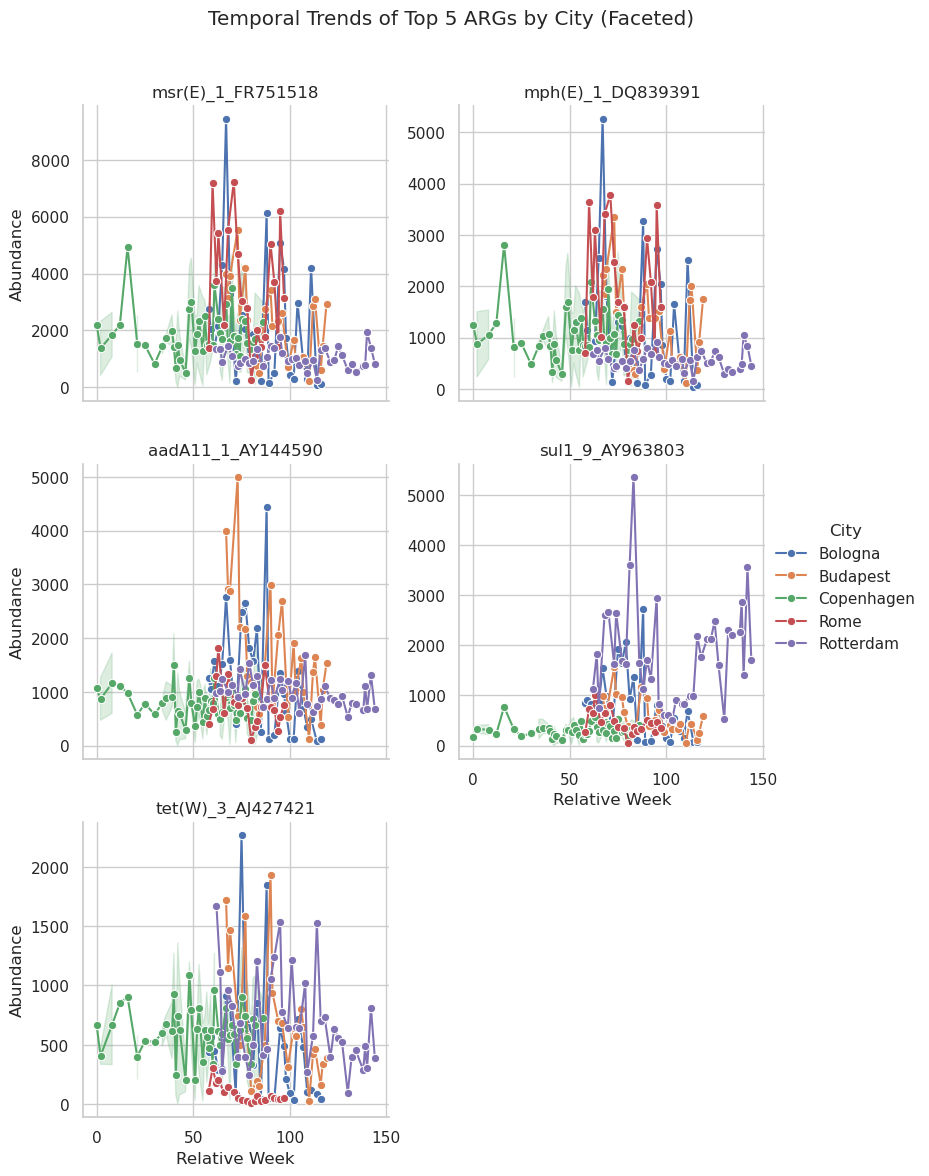

In [52]:
# ──────────────────────────────────────────────────────────────
# 0.  CONFIG – choose how many ARGs you want to visualise
TOP_N = 5          # e.g. 5 most abundant ARGs
SMOOTH   = False   # set True to plot a 3‑point rolling mean instead of raw values
ROLL_WIN = 3

# ──────────────────────────────────────────────────────────────
# 1.  BASIC CLEANING  (arg_df is assumed already in memory)
metadata_cols = ['CITY', 'relative_week', 'COLLECTION_DATE', 'sample_id']

arg_df_clean = arg_df
arg_numeric = (arg_df_clean
               .drop(columns=metadata_cols)                # remove meta for now
               .apply(pd.to_numeric, errors='coerce'))      # force numeric → NaN

# Re‑attach metadata
arg_numeric[metadata_cols] = arg_df_clean[metadata_cols]

# ──────────────────────────────────────────────────────────────
# 2.  PICK TOP‑N ARGs (by overall mean abundance)
top_args = (arg_numeric
            .drop(columns=metadata_cols)
            .mean()
            .sort_values(ascending=False)
            .head(TOP_N)
            .index.tolist())

# ──────────────────────────────────────────────────────────────
# 3.  LONG (TIDY) FORMAT FOR SEABORN
arg_long = arg_numeric.melt(id_vars=['relative_week', 'CITY'],
                            value_vars=top_args,
                            var_name='ARG',
                            value_name='Abundance')

# Optional smoothing per city–ARG pair
if SMOOTH:
    arg_long['Abundance'] = (arg_long
                             .sort_values(['ARG', 'CITY', 'relative_week'])
                             .groupby(['ARG', 'CITY'])['Abundance']
                             .transform(lambda s: s.rolling(ROLL_WIN, min_periods=1).mean()))

# ──────────────────────────────────────────────────────────────
# 4.  FACETED LINE PLOT
sns.set(style="whitegrid")

g = sns.FacetGrid(arg_long,
                  col="ARG",            # one facet per ARG
                  col_wrap=2,           # wrap every 2 columns of facets
                  height=4,             # size of each facet
                  sharey=False)         # each ARG gets its own y‑axis scale

g.map_dataframe(sns.lineplot,
                x='relative_week',
                y='Abundance',
                hue='CITY',
                marker='o')             # add markers for clarity

# Improve aesthetics
g.add_legend(title='City')
g.set_axis_labels("Relative Week", "Abundance")
g.set_titles("{col_name}")              # panel title = ARG name
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle(f"Temporal Trends of Top {TOP_N} ARGs by City (Faceted)")

plt.show()

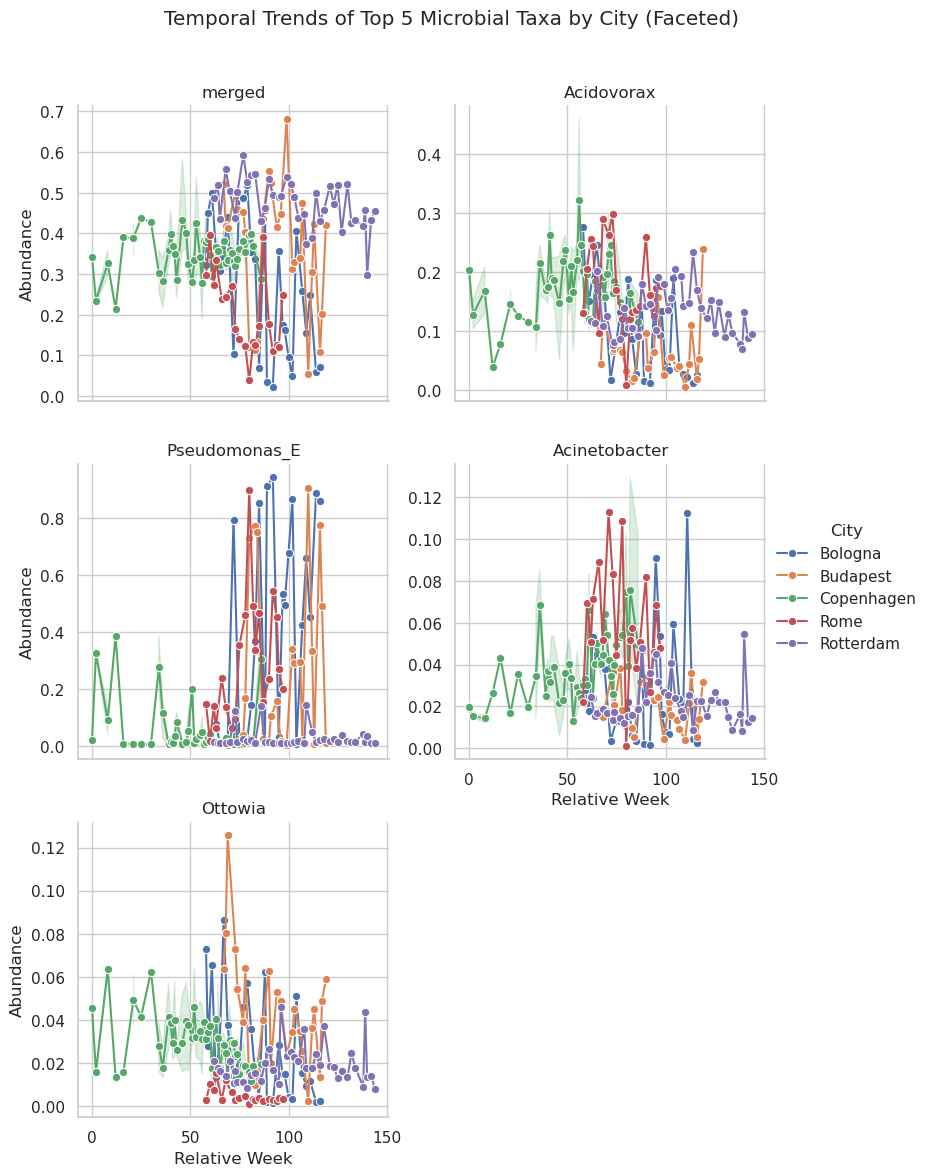

In [53]:
# ──────────────────────────────────────────────────────────────
# 0.  CONFIG
TOP_N_TAXA = 5      # Number of top microbial taxa to plot
SMOOTH = False      # Set to True for rolling average
ROLL_WIN = 3

# ──────────────────────────────────────────────────────────────
# 1.  BASIC CLEANING (abundance_df is assumed in memory)
metadata_cols = ['CITY', 'relative_week', 'COLLECTION_DATE', 'sample_id']

# Clean: replace blanks with NaNs
abundance_df_clean = abundance_df.replace(r'^\s*$', np.nan, regex=True)

# Extract and coerce only the taxa (non-metadata) columns to numeric
taxa_data = (abundance_df_clean
             .drop(columns=metadata_cols)
             .apply(pd.to_numeric, errors='coerce'))

# Reattach metadata
taxa_data[metadata_cols] = abundance_df_clean[metadata_cols]

# ──────────────────────────────────────────────────────────────
# 2.  SELECT TOP-N TAXA by mean abundance
top_taxa = (taxa_data
            .drop(columns=metadata_cols)
            .mean()
            .sort_values(ascending=False)
            .head(TOP_N_TAXA)
            .index.tolist())

# ──────────────────────────────────────────────────────────────
# 3.  LONG FORMAT FOR SEABORN
taxa_long = taxa_data.melt(id_vars=['relative_week', 'CITY'],
                           value_vars=top_taxa,
                           var_name='Taxa',
                           value_name='Abundance')

# Optional smoothing per city–taxa pair
if SMOOTH:
    taxa_long['Abundance'] = (taxa_long
                              .sort_values(['Taxa', 'CITY', 'relative_week'])
                              .groupby(['Taxa', 'CITY'])['Abundance']
                              .transform(lambda s: s.rolling(ROLL_WIN, min_periods=1).mean()))

# ──────────────────────────────────────────────────────────────
# 4.  FACETED TEMPORAL LINE PLOT
sns.set(style="whitegrid")

g = sns.FacetGrid(taxa_long,
                  col="Taxa",
                  col_wrap=2,
                  height=4,
                  sharey=False)

g.map_dataframe(sns.lineplot,
                x='relative_week',
                y='Abundance',
                hue='CITY',
                marker='o')

# Aesthetics
g.add_legend(title='City')
g.set_axis_labels("Relative Week", "Abundance")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle(f"Temporal Trends of Top {TOP_N_TAXA} Microbial Taxa by City (Faceted)")

plt.show()

### PCA Plots

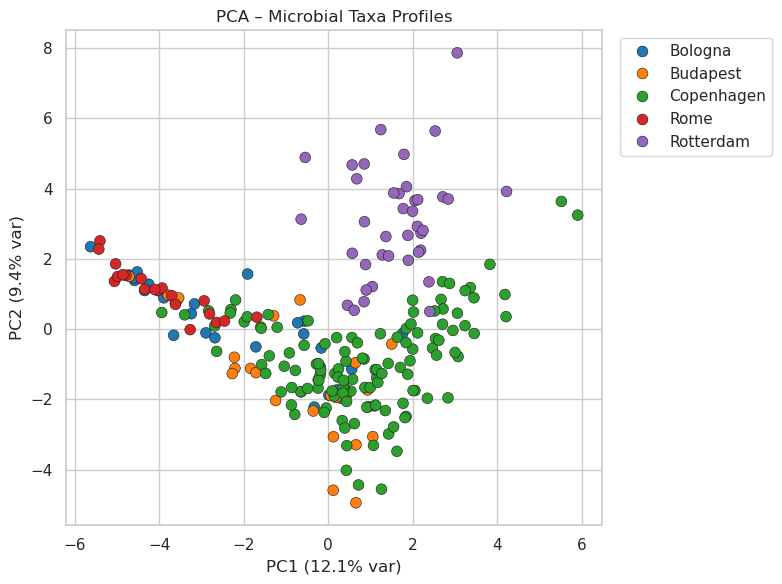

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── CONFIG ──────────────────────────────────────────────
metadata_cols = ['CITY', 'relative_week', 'COLLECTION_DATE', 'sample_id']
colour_by     = 'CITY'          # or 'relative_week'

# ── CLEAN + PREP ───────────────────────────────────────
abund = abundance_df.copy()
abund.replace(r'^\s*$', np.nan, regex=True, inplace=True)

X_taxa = abund.drop(columns=metadata_cols).apply(pd.to_numeric, errors='coerce')
X_taxa = X_taxa.dropna(axis=0, thresh=int(0.8 * X_taxa.shape[1]))     # keep rows w/ ≥80 % data
meta   = abund.loc[X_taxa.index, metadata_cols]

# ── STANDARDISE & PCA ──────────────────────────────────
X_scaled = StandardScaler().fit_transform(X_taxa.fillna(0))
pca      = PCA(n_components=2, random_state=42)
PCs      = pca.fit_transform(X_scaled)

# ── PLOT ───────────────────────────────────────────────
pca_df = pd.DataFrame(PCs, columns=['PC1', 'PC2']).join(meta.reset_index(drop=True))

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                hue=colour_by,
                palette='tab10' if colour_by=='CITY' else 'viridis',
                s=60, edgecolor='k', linewidth=0.4)
plt.title('PCA – Microbial Taxa Profiles')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout();  plt.show()


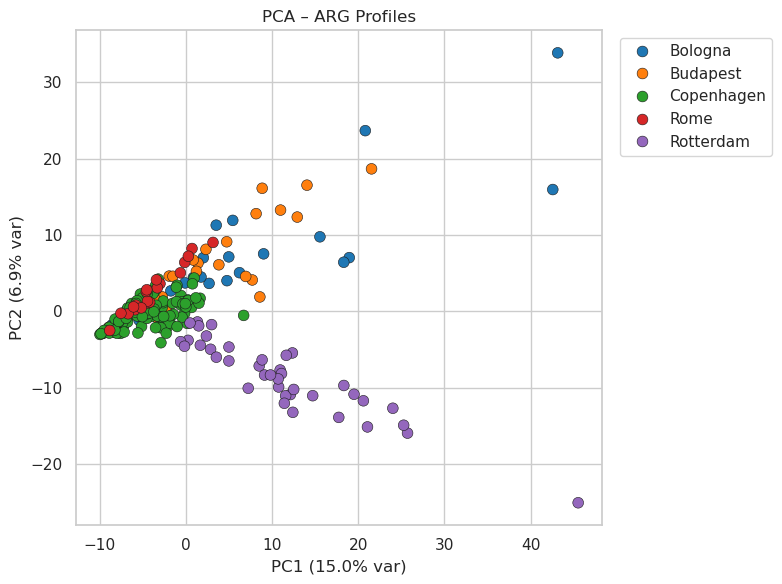

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── CONFIG ──────────────────────────────────────────────
metadata_cols = ['CITY', 'relative_week', 'COLLECTION_DATE', 'sample_id']
colour_by     = 'CITY'          # or 'relative_week'

# ── CLEAN + PREP ───────────────────────────────────────
arg = arg_df.copy()
arg.replace(r'^\s*$', np.nan, regex=True, inplace=True)

X_arg = arg.drop(columns=metadata_cols).apply(pd.to_numeric, errors='coerce')
X_arg = X_arg.dropna(axis=0, thresh=int(0.8 * X_arg.shape[1]))        # keep rows w/ ≥80 % data
meta  = arg.loc[X_arg.index, metadata_cols]

# ── STANDARDISE & PCA ──────────────────────────────────
X_scaled = StandardScaler().fit_transform(X_arg.fillna(0))
pca      = PCA(n_components=2, random_state=42)
PCs      = pca.fit_transform(X_scaled)

# ── PLOT ───────────────────────────────────────────────
pca_df = pd.DataFrame(PCs, columns=['PC1', 'PC2']).join(meta.reset_index(drop=True))

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                hue=colour_by,
                palette='tab10' if colour_by=='CITY' else 'viridis',
                s=60, edgecolor='k', linewidth=0.4)
plt.title('PCA – ARG Profiles')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout();  plt.show()


In [61]:
X_taxa.columns

Index(['Acidovorax', 'Acinetobacter', 'Aeromonas', 'Aliarcobacter',
       'Aquabacterium_A', 'Bacteroides', 'Brachymonas', 'Brevefilum',
       'Brevundimonas', 'Cloacibacterium', 'Comamonas', 'Competibacter_A',
       'Enterobacter', 'Fermentibacter', 'Flavobacterium', 'Giesbergeria',
       'Hydrogenophaga', 'JAGOYM01', 'Janthinobacterium', 'Kaistella',
       'Lactococcus_A', 'Lenti-01', 'Microthrix', 'Moraxella_A', 'Neisseria',
       'Novosphingobium', 'Ottowia', 'Paracoccus', 'Phocaeicola', 'Prevotella',
       'Propionivibrio', 'Pseudomonas_E', 'Pseudoxanthomonas',
       'Pseudoxanthomonas_A', 'Psychrobacter', 'Rubrivivax', 'Streptococcus',
       'Telluria', 'Thauera', 'Thermomonas', 'Thiothrix', 'Tolumonas',
       'Trichococcus', 'UBA1413', 'merged'],
      dtype='object')

## 4. Time-Series Modeling

- Group data by site (CITY/PLANT)

- Convert into time-series format (weekly granularity using relative_week)

- Possible models:

   - Univariate: ARIMA/ETS for specific ARGs or taxa

   - Multivariate: VAR/VECM or LSTM/GRU neural networks for multiple ARGs/taxa

- Seasonality & trend detection

## 5. Network Analysis

- Co-occurrence networks:

   - ARG–microbe co-abundance networks

   - Use Spearman or SparCC for correlation

   -  Visualize with NetworkX or Cytoscape

## 6. Site-Specific & Comparative Analysis

- Compare cities or treatment plants:

- Bray-Curtis dissimilarity

- PERMANOVA or ANOSIM

- Differential abundance (DESeq2 or ALDEx2-like models)

## 7. ML-based Forecasting or Classification

## 8. Visualizations for Communication

- Interactive dashboards (Plotly, Streamlit)

- Sankey plots, temporal heatmaps, taxonomic trees

- Combine timelines with external factors

## 9. Validation & Interpretation

- Biological interpretation of findings

- Consult domain experts: microbiologists, epidemiologists

- Cross-validate across sites and weeks